# **Análisis exploratorio de Datos**

In [21]:
#Descargamos el dataset
import kagglehub

# Descargar el dataset completo
path = kagglehub.dataset_download("mirzayasirabdullah07/student-exam-scores-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-exam-scores-dataset' dataset.
Path to dataset files: /kaggle/input/student-exam-scores-dataset


In [22]:
#Importamos CV
import pandas as pd
import os

# Ruta al archivo descargado
csv_path = os.path.join(path, "student_exam_scores.csv")

# Leer el CSV
df = pd.read_csv(csv_path)

df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [23]:
print(df.shape)

(200, 6)


In [24]:
#Verificar valores nulos
print(df.isnull().sum())


student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64


In [25]:
print(df.shape)

(200, 6)


In [26]:
# Verificamos valores duplicados

df.duplicated().sum()

np.int64(0)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


No hay valores duplicados

Revisaremos la distribución de los datos

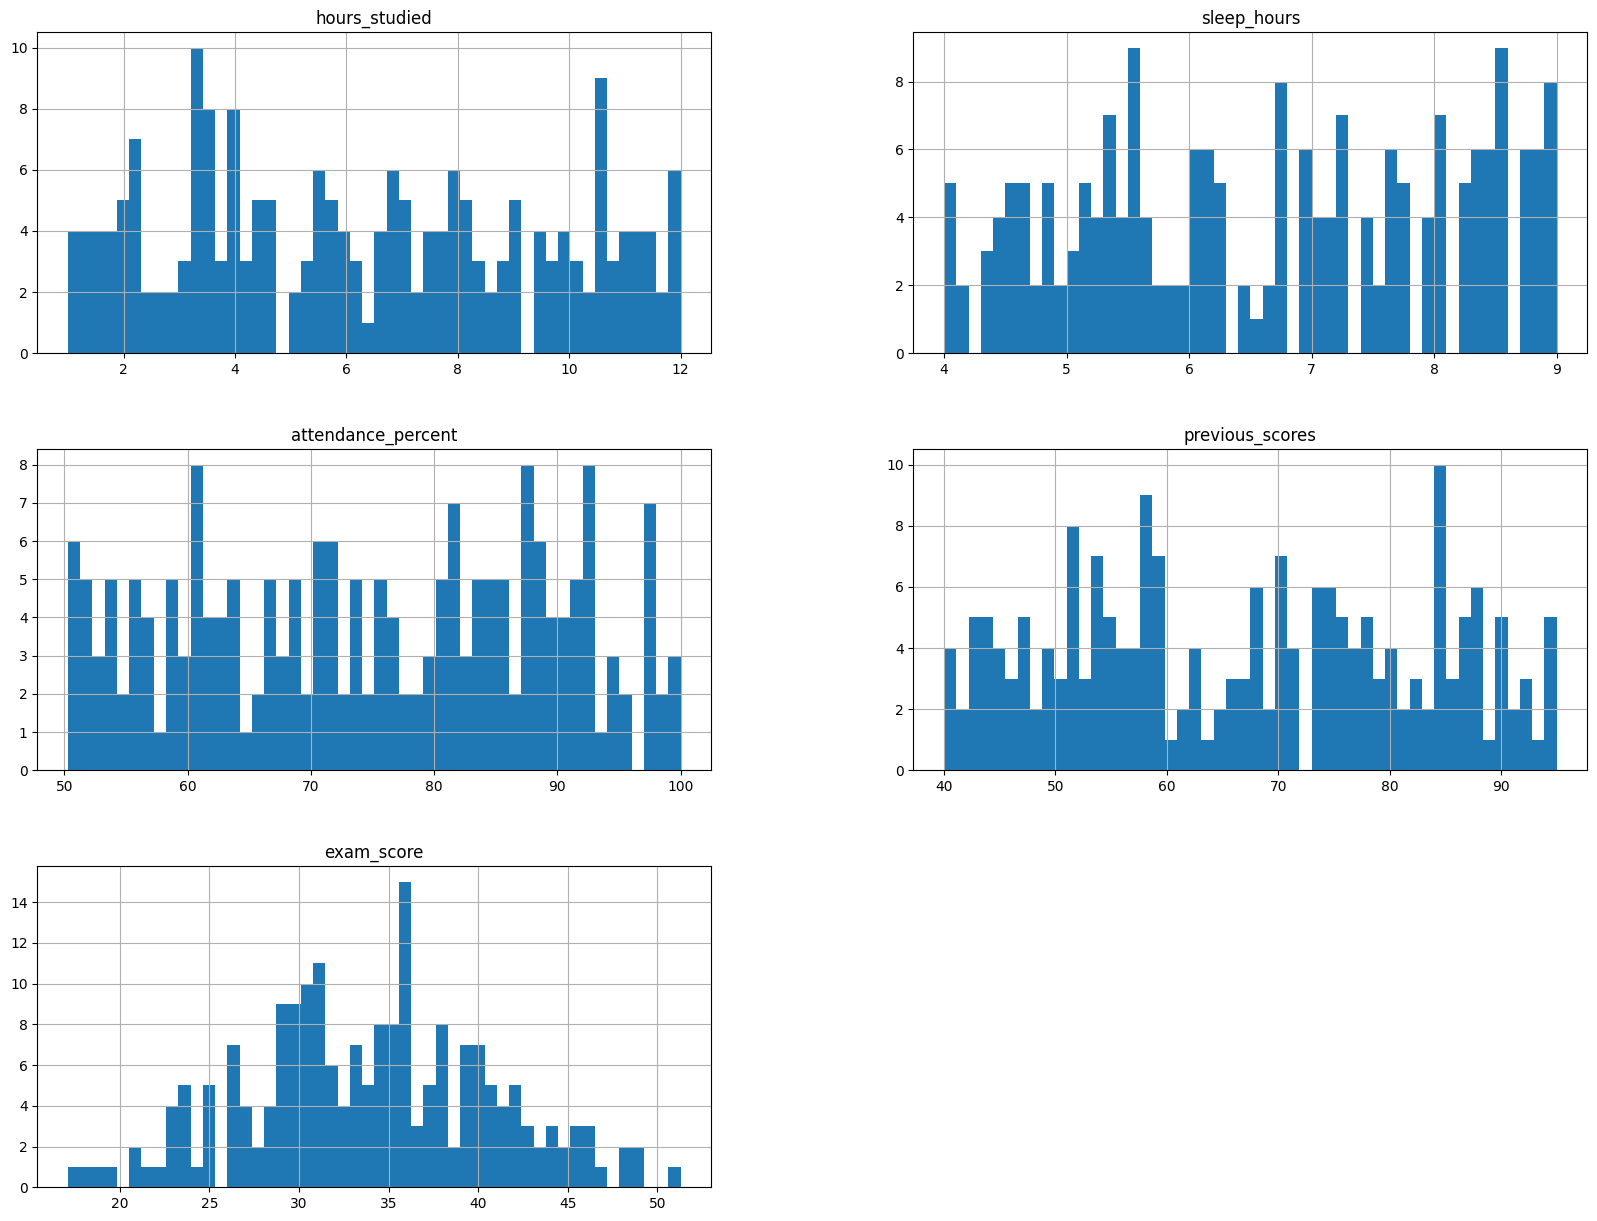

In [28]:
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20,15))
plt.show()

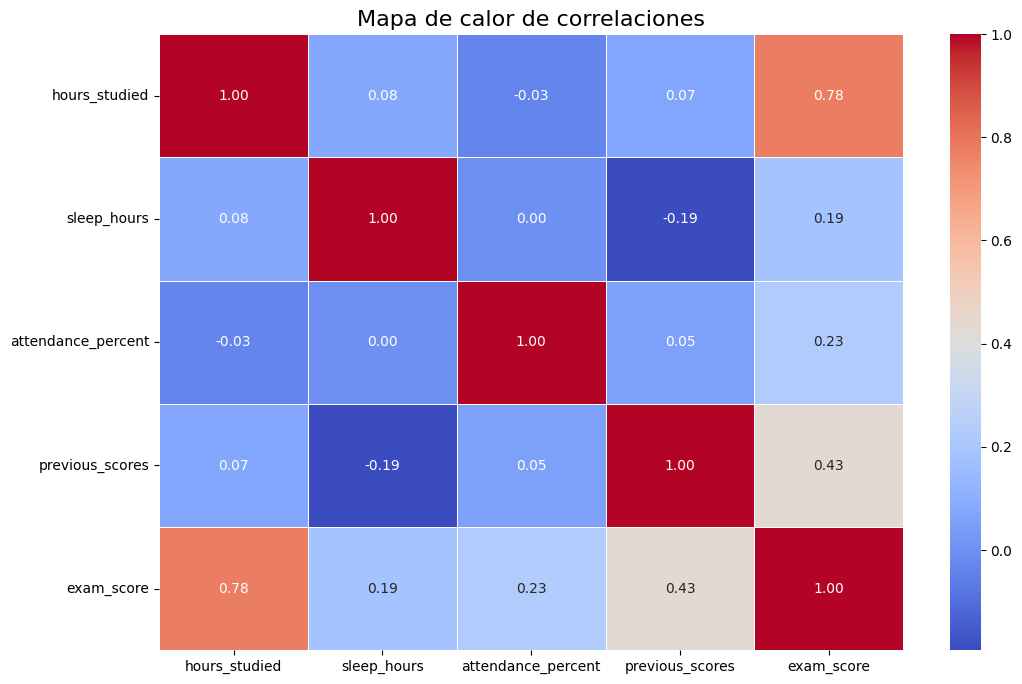

In [29]:
#Mapa de calor de correlaciones
import seaborn as sns


corr = df.corr(numeric_only=True)

# Crear el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de calor de correlaciones", fontsize=16)
plt.show()

El mapa de calor, muestra que las varibles están altamente correlacionadas unas entre otras, las que representan mayores valores de correlación son year_resale_value y Price_in_thousands. Por otro lado, horsepower y power_perf_factor tienen gran correlación también.

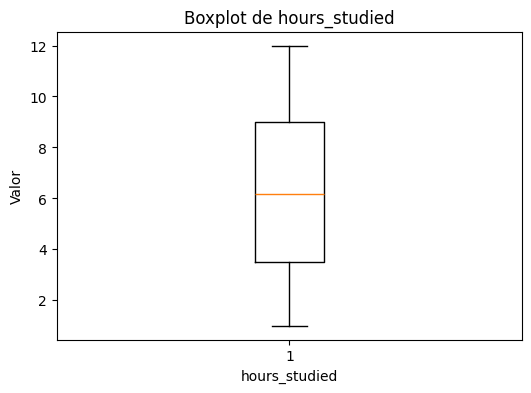

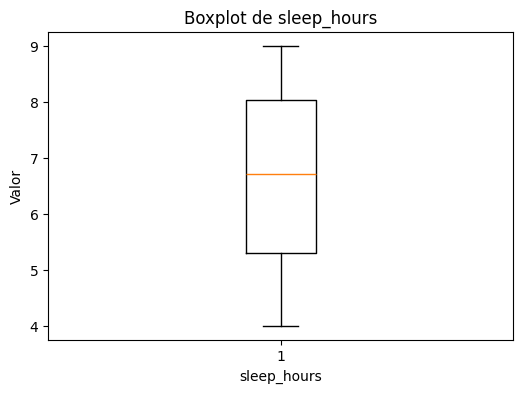

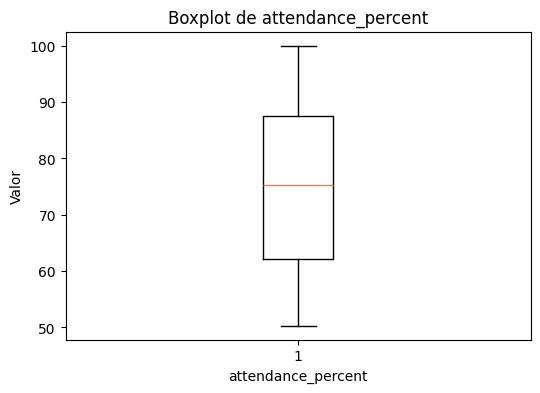

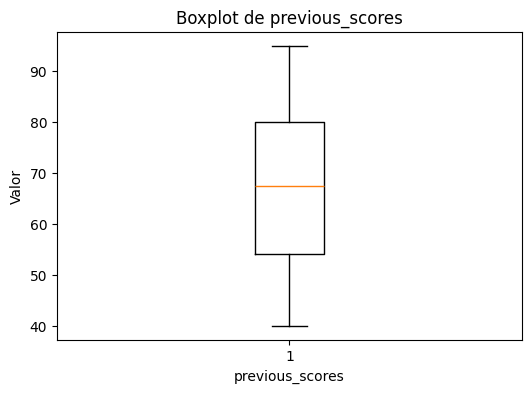

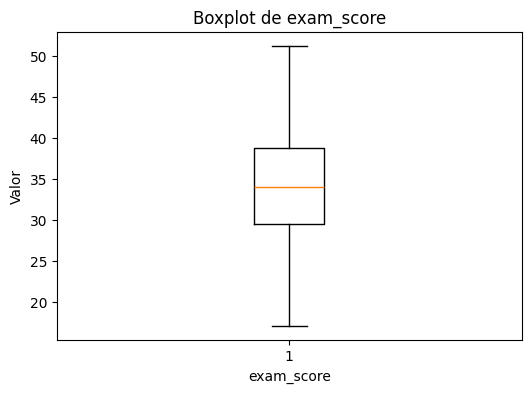

In [30]:
numericas = df.select_dtypes(include=['int64', 'float64']).columns
# Crear boxplot para cada variable
for col in numericas:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.ylabel("Valor")
    plt.show()

Las variables que no presentan outliers

# Preparación de los datos para Implementar los modelos

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier, LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from time import time # Import the time function

Revisamos variables categóricas y convertimos a variables numéricas

In [32]:
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


Todas las variables son numéricas, descartando el student_id, en la cual eliminaremos la letra S, no debemos hacer hot encoder en la base de datos



In [33]:
df['student_id'] = df['student_id'].str.lstrip('S')

Creamos el conjunto de la variable objetivo y las demás

In [34]:
X = df.drop(['exam_score'], axis=1)
y = df['exam_score']

Escalamos las variables explicativas para estandarizar el rango de las variables, debido a que los rangos de los valores varían considerablemente

In [35]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X = scale.fit_transform(X)

In [36]:
# Separamos el conjunto de datos en los de entreno y lo de evaluación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set',X_train.shape,y_train.shape)
print('Testing set',X_test.shape,y_test.shape)

Training set (160, 5) (160,)
Testing set (40, 5) (40,)


# Modelo de Regresión

In [37]:
def regression(model, model_name, X_train, y_train):
    start_time = time()  # Grabar el tiempo de inicio
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2_score = model.score(X_test,y_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    plt.figure()
    plt.plot(y_test, y_test)
    plt.scatter(y_test, y_pred, s=10, c="red")
    pred_clf = model.predict(X_test)
    plt.title(f"{model_name} : R2_score = {round(r2_score,2)}, MAE = {round(mae,2)}, RMSE = {round(rmse,2)}")
    plt.xlabel("Actual values")
    plt.ylabel("Predicted values")
    plt.show()
    end_time = time()  # Record end time
    execution_time = end_time - start_time  # Calculate execution time
    return r2_score, mae, rmse, execution_time



In [38]:
results_re = pd.DataFrame(columns=['model_name', 'r2_score', 'mae', 'rmse', 'execution_time'])

# Regresión Lineal

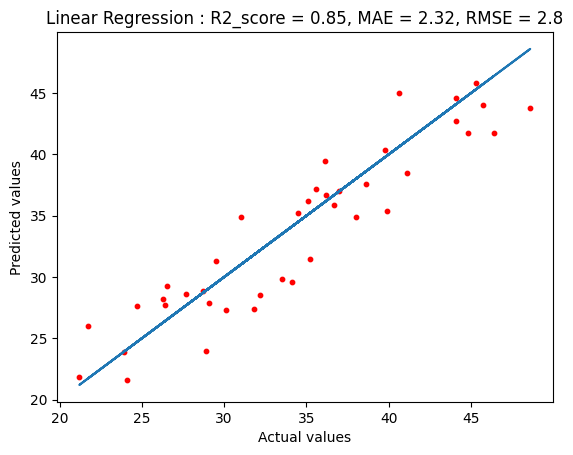

/tmp/ipython-input-1611548515.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_re = pd.concat([results_re, pd.DataFrame([{'model_name': model_name, 'r2_score': r2_score, 'mae': mae, 'rmse': rmse, 'execution_time':execution_time}])], ignore_index=True)


,model_name,r2_score,mae,rmse,execution_time
0,Linear Regression,0.851812,2.324418,2.804349,0.187466


In [39]:
model = LinearRegression()
model_name = "Linear Regression"
r2_score, mae, rmse, execution_time = regression(model, model_name, X_train, y_train)
results_re = pd.concat([results_re, pd.DataFrame([{'model_name': model_name, 'r2_score': r2_score, 'mae': mae, 'rmse': rmse, 'execution_time':execution_time}])], ignore_index=True)
results_re


# Regresión Polinomica

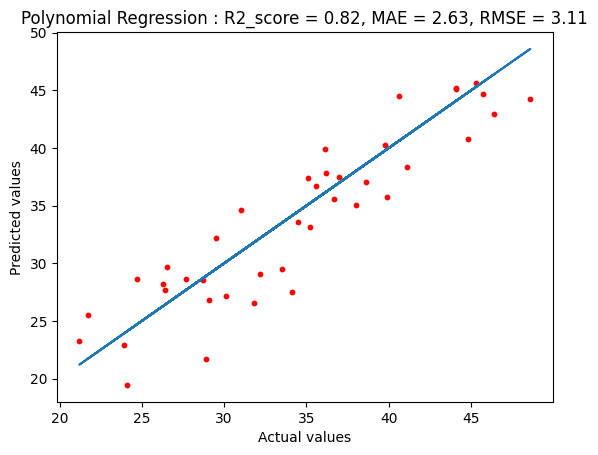

,model_name,r2_score,mae,rmse,execution_time
0,Linear Regression,0.851812,2.324418,2.804349,0.187466
1,Polynomial Regression,0.817197,2.625908,3.114705,0.195025


In [40]:
degree =  2 # You can adjust the degree as needed
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_name = "Polynomial Regression"
r2_score, mae, rmse, execution_time = regression(model, model_name, X_train, y_train)
results_re = pd.concat([results_re, pd.DataFrame([{'model_name': model_name, 'r2_score': r2_score, 'mae': mae, 'rmse': rmse, 'execution_time':execution_time}])], ignore_index=True)
results_re

# Árbol de Decisiones

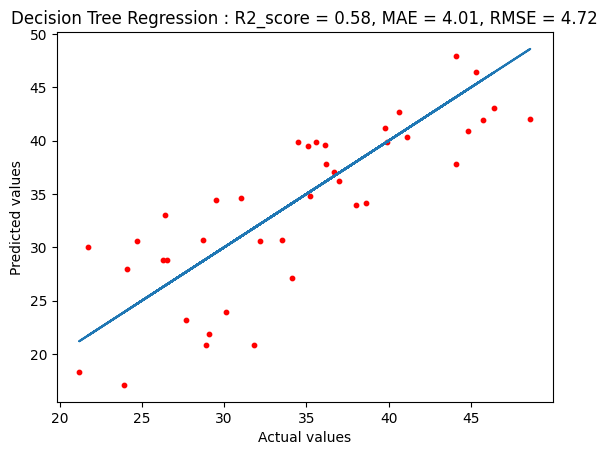

,model_name,r2_score,mae,rmse,execution_time
0,Linear Regression,0.851812,2.324418,2.804349,0.187466
1,Polynomial Regression,0.817197,2.625908,3.114705,0.195025
2,Decision Tree Regression,0.580385,4.010000,4.719004,0.226162


In [41]:
model = DecisionTreeRegressor(random_state=0, max_depth=17)
model_name = "Decision Tree Regression"
r2_score, mae, rmse, execution_time = regression(model, model_name, X_train, y_train)
results_re = pd.concat([results_re, pd.DataFrame([{'model_name': model_name, 'r2_score': r2_score, 'mae': mae, 'rmse': rmse, 'execution_time':execution_time}])], ignore_index=True)
results_re

# Regresión Random Forest

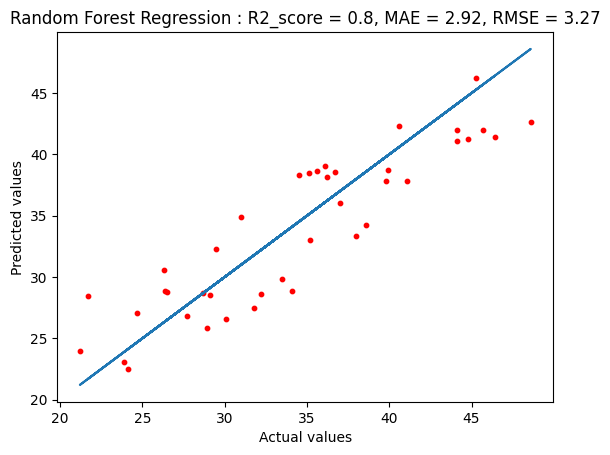

,model_name,r2_score,mae,rmse,execution_time
0,Linear Regression,0.851812,2.324418,2.804349,0.187466
1,Polynomial Regression,0.817197,2.625908,3.114705,0.195025
2,Decision Tree Regression,0.580385,4.010000,4.719004,0.226162
3,Random Forest Regression,0.798023,2.915700,3.273981,0.535817


In [42]:
model = RandomForestRegressor(random_state=0)
model_name = "Random Forest Regression"
r2_score, mae, rmse, execution_time = regression(model, model_name, X_train, y_train)
results_re = pd.concat([results_re, pd.DataFrame([{'model_name': model_name, 'r2_score': r2_score, 'mae': mae, 'rmse': rmse, 'execution_time':execution_time}])], ignore_index=True)
results_re

# Regresión de vectores de soporte

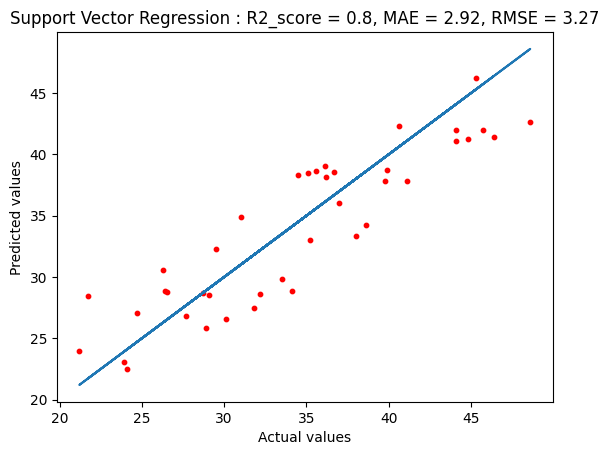

,model_name,r2_score,mae,rmse,execution_time
0,Linear Regression,0.851812,2.324418,2.804349,0.187466
1,Polynomial Regression,0.817197,2.625908,3.114705,0.195025
2,Decision Tree Regression,0.580385,4.010000,4.719004,0.226162
3,Random Forest Regression,0.798023,2.915700,3.273981,0.535817
4,Support Vector Regression,0.798023,2.915700,3.273981,0.509953


In [43]:
clf = SVR(kernel='rbf',epsilon=1.0) #rbf = Función de base radial
model_name = "Support Vector Regression"
r2_score, mae, rmse, execution_time = regression(model, model_name, X_train, y_train)
results_re = pd.concat([results_re, pd.DataFrame([{'model_name': model_name, 'r2_score': r2_score, 'mae': mae, 'rmse': rmse, 'execution_time':execution_time}])], ignore_index=True)
results_re

# Regresión de Cresta

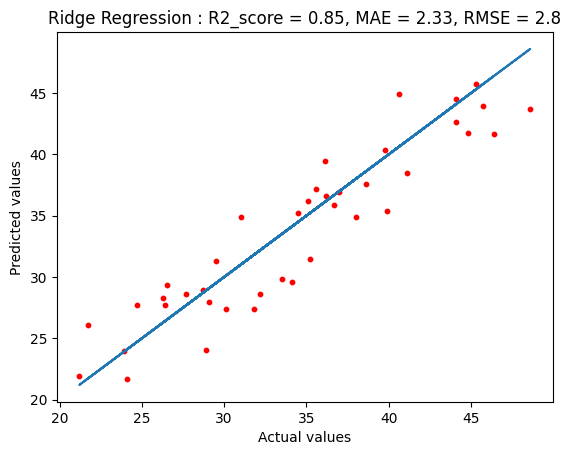

,model_name,r2_score,mae,rmse,execution_time
0,Linear Regression,0.851812,2.324418,2.804349,0.187466
1,Polynomial Regression,0.817197,2.625908,3.114705,0.195025
2,Decision Tree Regression,0.580385,4.010000,4.719004,0.226162
3,Random Forest Regression,0.798023,2.915700,3.273981,0.535817
4,Support Vector Regression,0.798023,2.915700,3.273981,0.509953
5,Ridge Regression,0.851934,2.326750,2.803188,0.201385


In [44]:
model = Ridge(alpha=1.0)
model_name = "Ridge Regression"
r2_score, mae, rmse, execution_time = regression(model, model_name, X_train, y_train)
results_re = pd.concat([results_re, pd.DataFrame([{'model_name': model_name, 'r2_score': r2_score, 'mae': mae, 'rmse': rmse, 'execution_time':execution_time}])], ignore_index=True)
results_re

# Regresión de lazo

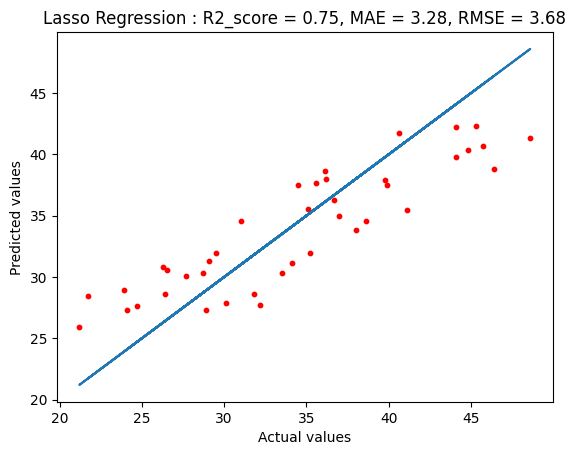

,model_name,r2_score,mae,rmse,execution_time
0,Linear Regression,0.851812,2.324418,2.804349,0.187466
1,Polynomial Regression,0.817197,2.625908,3.114705,0.195025
2,Decision Tree Regression,0.580385,4.010000,4.719004,0.226162
3,Random Forest Regression,0.798023,2.915700,3.273981,0.535817
4,Support Vector Regression,0.798023,2.915700,3.273981,0.509953
5,Ridge Regression,0.851934,2.326750,2.803188,0.201385
6,Lasso Regression,0.745257,3.284330,3.676852,0.228275


In [45]:
# Lasso Regression
model = Lasso(alpha=1.0)
model_name = "Lasso Regression"
r2_score, mae, rmse, execution_time = regression(model, model_name, X_train, y_train)
results_re = pd.concat([results_re, pd.DataFrame([{'model_name': model_name, 'r2_score': r2_score, 'mae': mae, 'rmse': rmse, 'execution_time':execution_time}])], ignore_index=True)
results_re